In [1]:
import pandas as pd
import numpy as np
from scipy.sparse import coo_matrix
import scipy as sp
from matplotlib import pyplot as plt

# read data
Downloaded from: https://male-cns.janelia.org/ (link provided in the [maleCNS manuscript](https://www.biorxiv.org/content/10.1101/2025.10.09.680999v1)). 

In [2]:
meta = pd.read_feather("~/Downloads/body-annotations-male-cns-v0.9-minconf-0.5.feather")
meta.rename(columns={"bodyId": "bodyid"}, inplace=True)
meta

,bodyid,flywireType,group,hemibrainType,instance,itoleeHl,somaSide,statusLabel,superclass,supertype,...,synonyms,birthtime,mancSerial,mcnsSerial,exitNerve,serialMotif,receptorType,somaLocation,tosomaLocation,status
0,10001,DNp01,10001.0,Giant Fiber,DNp01(GF)_R,putative_primary,R,Roughly traced,descending_neuron,NaN,...,Kennedy and Broadie 2018: GF,early,NaN,NaN,NaN,NaN,NaN,"[37124, 22258, 36274]",None,Traced
1,10002,OCG01d,10002.0,OCG01,OCG01d_L,NaN,L,Roughly traced,visual_projection,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"[50214, 10279, 27497]",None,Traced
2,10003,VCH,10003.0,VCH,VCH_R,putative_primary,R,Prelim Roughly traced,visual_centrifugal,NaN,...,NaN,early,NaN,NaN,NaN,NaN,NaN,"[46716, 21029, 15714]",None,Traced
3,10005,AOTU019,10005.0,AOTU019,AOTU019_R,putative_primary,R,Roughly traced,cb_intrinsic,NaN,...,NaN,early,NaN,NaN,NaN,NaN,NaN,"[41190, 18491, 12885]",None,Traced
4,10006,"VS1,VS2,VS3,VS4,VS5,VS6,VS7,VS8",10006.0,VS,VS_L,no_lineage,L,Prelim Roughly traced,visual_projection,10006,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"[69604, 28368, 42459]",None,Traced
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
211738,1571382316,NaN,NaN,NaN,NaN,NaN,NaN,Glia,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,None,Glia
211739,1571573938,NaN,NaN,NaN,NaN,NaN,NaN,Glia,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,None,Glia
211740,1571585036,NaN,NaN,NaN,NaN,NaN,NaN,Glia,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,None,Glia
211741,1571679990,NaN,NaN,NaN,NaN,NaN,NaN,Glia,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,None,Glia


In [3]:
meta.columns

Index(['bodyid', 'flywireType', 'group', 'hemibrainType', 'instance',
       'itoleeHl', 'somaSide', 'statusLabel', 'superclass', 'supertype',
       'type', 'class', 'entryNerve', 'fruDsx', 'matchingNotes', 'rootSide',
       'assignedOlHex1', 'assignedOlHex2', 'mancBodyid', 'mancGroup',
       'mancType', 'somaNeuromere', 'subclass', 'trumanHl', 'dimorphism',
       'synonyms', 'birthtime', 'mancSerial', 'mcnsSerial', 'exitNerve',
       'serialMotif', 'receptorType', 'somaLocation', 'tosomaLocation',
       'status'],
      dtype='str')

In [4]:
nt = pd.read_feather("~/Downloads/body-neurotransmitters-male-cns-v0.9.feather")
id2nt = dict(zip(nt.body, nt.consensus_nt))
nt

,body,cell_type,total_nt_predictions,predicted_nt_confidence,predicted_nt,ground_truth,celltype_total_nt_predictions,celltype_predicted_nt,celltype_predicted_nt_confidence,consensus_nt
0,10001,DNp01,1015,0.500352,acetylcholine,NaN,1991,acetylcholine,0.528112,acetylcholine
1,10002,OCG01d,1443,0.955596,acetylcholine,NaN,2818,acetylcholine,0.956176,acetylcholine
2,10003,VCH,4425,0.879395,gaba,gaba,8721,gaba,0.874869,gaba
3,10005,AOTU019,2837,0.835142,gaba,gaba,5673,gaba,0.830569,gaba
4,10006,VS,426,0.903854,acetylcholine,acetylcholine,5260,acetylcholine,0.819789,acetylcholine
...,...,...,...,...,...,...,...,...,...,...
1836288,1571851631,NaN,1,0.910987,unclear,NaN,1,unclear,NaN,unclear
1836289,1571851794,NaN,1,0.910987,unclear,NaN,1,unclear,NaN,unclear
1836290,1571860301,NaN,1,0.974427,unclear,NaN,1,unclear,NaN,unclear
1836291,1571860934,NaN,1,0.974427,unclear,NaN,1,unclear,NaN,unclear


In [5]:
# remove entries without superclass/type
meta = meta[meta.superclass.notna() & meta['type'].notna()]
# add nt
meta["top_nt"] = meta.bodyid.map(id2nt)

In [6]:
conn = pd.read_feather("~/Downloads/syn-partners-male-cns-v0.9-minconf-0.5.feather")
# only keep the ones in meta
conn = conn[conn.body_pre.isin(meta.bodyid) & conn.body_post.isin(meta.bodyid)]
# NOTE: lamina is damaged in this dataset according to Nern et al. 2024 (https://www.nature.com/articles/s41586-025-08746-0), so remove all LA connectivity
# so please take large monopolar cells (e.g. L1-L3), and R7 & R8 as the location of visual input, instead of R1-6
conn = conn[~conn.primary_post.isin(["LA(L)", "LA(R)"])]
# then only keep the ones with connectivity for meta
connids = set(conn.body_pre).union(set(conn.body_post))
meta = meta[meta.bodyid.isin(connids)]
conn

,x_pre,y_pre,z_pre,body_pre,conf_pre,x_post,y_post,z_post,body_post,conf_post,primary_post
466,34048,28501,9546,13670,0.760,34032,28519,9556,520132,0.887241,<unspecified>
468,34048,28501,9546,13670,0.760,34045,28490,9558,122957,1.000000,<unspecified>
608,57359,25509,10066,143391,0.772,57364,25492,10070,345940,0.999999,CentralBrain-unspecified
609,57359,25509,10066,143391,0.772,57359,25503,10081,190342,0.999998,CentralBrain-unspecified
655,56972,26015,10092,198518,0.872,56964,26026,10076,292769,0.999859,CentralBrain-unspecified
...,...,...,...,...,...,...,...,...,...,...,...
311833195,50867,44764,134295,809492,0.738,50869,44759,134282,806047,1.000000,VNC-unspecified
311833200,51789,46466,134369,911047,0.727,51775,46460,134358,908012,1.000000,AbNT(L)
311833201,51789,46466,134369,911047,0.727,51804,46466,134358,809171,1.000000,AbNT(L)
311833215,52994,44651,134454,907324,0.770,52987,44636,134451,810301,1.000000,AbN4(L)


In [7]:
conn = conn.groupby(["body_pre", "body_post"]).size().reset_index(name="weight")
conn

,body_pre,body_post,weight
0,10001,10010,1
1,10001,10052,1
2,10001,10078,1
3,10001,10091,5
4,10001,10106,9
...,...,...,...
25070536,1471062202,908011,1
25070537,1471062202,909839,4
25070538,1471062202,928813,1
25070539,1471062202,1053002338,3


In [8]:
# as instructed, remove weight < 5 
# conn = conn[conn.weight >= 5]

In [9]:
# average number of synapses per connection
conn["weight"].mean()

np.float64(4.860246494082437)

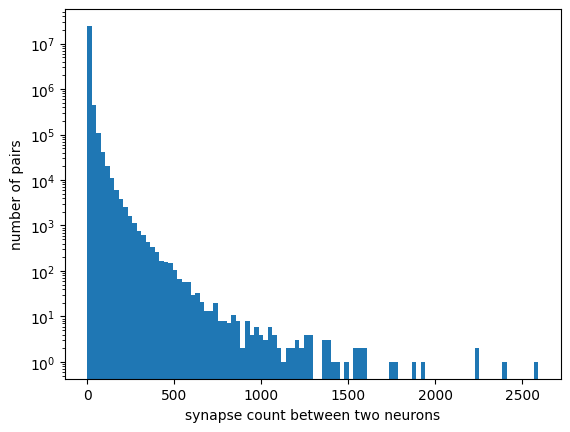

In [10]:
# histogram
plt.hist(conn["weight"], bins=100)

plt.xlabel("synapse count between two neurons")
plt.ylabel("number of pairs")
plt.yscale("log")

In [11]:
# how many neurons are there?
allids = set(conn.body_pre).union(set(conn.body_post))
allids = allids.intersection(set(meta.bodyid))
len(allids)

161416

In [12]:
# how many GB for dense matrix?
len(allids) ** 2 * 4 / 1e9

104.220500224

## exploration

In [13]:
# in connectivity but not meta
len(allids - set(meta.bodyid))

0

In [14]:
# in meta but not connectivity
len(set(meta.bodyid) - allids)

0

In [15]:
# check ones that are not in connectivity
meta[~meta.bodyid.isin(allids)].status.value_counts()

Series([], Name: count, dtype: int64)

There are a few hundred that are roughly traced. 

In [16]:
meta["superclass"].value_counts(dropna=False)

superclass
ol_intrinsic             89306
cb_intrinsic             31264
vnc_intrinsic            12967
visual_projection         9200
vnc_sensory               5609
cb_sensory                4679
ol_sensory                3152
ascending_neuron          1841
descending_neuron         1310
vnc_motor                  711
visual_centrifugal         562
sensory_ascending          527
cb_motor                   106
vnc_efferent                86
endocrine                   64
sensory_descending          12
efferent_ascending           8
efferent_descending          4
cb_efferent                  4
visual_projection_tbc        2
sensory_ascending_tbc        1
cb_sensory_tbc               1
Name: count, dtype: int64

In [17]:
meta["class"].value_counts(dropna=False)

class
NaN                              138817
Kenyon_Cell                        4064
visual                             3145
CX                                 2950
olfactory                          2635
mechanosensory_tactile             2504
mechanosensory                     1627
gustatory                          1416
mechanosensory_proprioceptive      1383
unknown_sensory                    1052
ALPN                                693
ALLN                                399
DAN                                 340
ol_bilateral                        116
MBON                                 97
hygrosensory                         66
chemosensory                         48
thermosensory                        25
ALIN                                 24
ALON                                 14
mechanosensory_tbc                    1
Name: count, dtype: int64

In [18]:
meta[["somaSide", "rootSide"]].value_counts(dropna=False)

somaSide  rootSide
R         NaN         73622
L         NaN         73438
NaN       R            7223
          L            6316
          unknown       411
M         NaN           375
L         L              22
R         R               5
NaN       NaN             3
L         R               1
Name: count, dtype: int64

# make combined_type column

In [19]:
meta.columns

Index(['bodyid', 'flywireType', 'group', 'hemibrainType', 'instance',
       'itoleeHl', 'somaSide', 'statusLabel', 'superclass', 'supertype',
       'type', 'class', 'entryNerve', 'fruDsx', 'matchingNotes', 'rootSide',
       'assignedOlHex1', 'assignedOlHex2', 'mancBodyid', 'mancGroup',
       'mancType', 'somaNeuromere', 'subclass', 'trumanHl', 'dimorphism',
       'synonyms', 'birthtime', 'mancSerial', 'mcnsSerial', 'exitNerve',
       'serialMotif', 'receptorType', 'somaLocation', 'tosomaLocation',
       'status', 'top_nt'],
      dtype='str')

In [20]:
meta[['flywireType','hemibrainType','type','mancType']].notna().value_counts(dropna=False)

flywireType  hemibrainType  type  mancType
True         False          True  False       103625
             True           True  False        32292
False        False          True  True         20173
                                  False         2724
True         False          True  True          2140
             True           True  True           428
False        True           True  False           34
Name: count, dtype: int64

let's say mcns type > flywire type > hemibrain type > manc type > bodyid for now. 

In [21]:
# use type column when there is a value and flywire_type when there is not, and bodyid as a last resort
meta.loc[:, ["combined_type"]] = meta["type"]
meta.combined_type.replace("", np.nan, inplace=True)

meta.combined_type.fillna(meta["flywireType"], inplace=True)
meta.combined_type.replace("", np.nan, inplace=True)

meta.combined_type.fillna(meta["hemibrainType"], inplace=True)
meta.combined_type.replace("", np.nan, inplace=True)

meta.combined_type.fillna(meta["mancType"], inplace=True)
meta.combined_type.replace("", np.nan, inplace=True)

meta.combined_type.fillna(meta["bodyid"].astype(str), inplace=True)
meta.combined_type.isna().sum()

C:\Users\44745\AppData\Local\Temp\ipykernel_44604\1965041994.py:3: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  meta.combined_type.replace("", np.nan, inplace=True)
C:\Users\44745\AppData\Local\Temp\ipykernel_44604\1965041994.py:5: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assign

np.int64(0)

In [22]:
# make dictionary that maps bodyid to type
bodyid2type = meta.set_index("bodyid")["combined_type"].to_dict()
bodyid2superclass = meta.set_index("bodyid")["superclass"].to_dict()

# add to conn
conn.loc[:, "comb_type_pre"] = conn.body_pre.map(bodyid2type)
conn.loc[:, "comb_type_post"] = conn.body_post.map(bodyid2type)

In [23]:
# take the intersection of meta and conn
selected_meta = meta[meta.bodyid.isin(allids)]
conn = conn[
    conn.body_pre.isin(selected_meta.bodyid) & conn.body_post.isin(selected_meta.bodyid)
]

In [24]:
# calculate the total post-synapses for each neuron
# do this after removing the ids we don't care about
total_post = conn.groupby("body_post").weight.sum()
total_pre = conn.groupby("body_pre").weight.sum()

# some neurons have no postsynapses (receptors). Let's add those to total_post with value of 0
no_post = allids - set(total_post.index)
no_pre = allids - set(total_pre.index)
len(no_post)

364

In [25]:
no_post_dict = dict(zip(no_post, np.zeros(len(no_post), dtype=int)))
no_pre_dict = dict(zip(no_pre, np.zeros(len(no_pre), dtype=int)))
total_post = pd.concat([total_post, pd.Series(no_post_dict)])
total_pre = pd.concat([total_pre, pd.Series(no_pre_dict)])

# NT

In [26]:
meta.top_nt.value_counts(dropna=False)

top_nt
acetylcholine    98509
glutamate        28758
gaba             21859
histamine         4939
dopamine          4454
unclear           2802
octopamine          51
serotonin           44
Name: count, dtype: int64

In [27]:
# first check consistency of NT within each type
meta.loc[:, ["top_nt"]] = meta["top_nt"].fillna("unclear")
nt_count_per_type = meta.groupby("combined_type")["top_nt"].nunique()
nt_count_per_type[nt_count_per_type > 1]

Series([], Name: top_nt, dtype: int64)

In [28]:
# For those with different NT for each neuron, get the majority NT for each type
nt_conflict_types = nt_count_per_type[nt_count_per_type > 1].index

# Getting counts of top_nt for each combined_type
nt_conflict_type_counts = (
    meta[meta.combined_type.isin(nt_conflict_types)]
    .groupby(["combined_type", "top_nt"])
    .size()
)

# Convert the series to a DataFrame and reset index
nt_conflict_type_counts = nt_conflict_type_counts.reset_index(name="counts")

# Sort by combined_type and counts in descending order
nt_conflict_type_counts.sort_values(
    by=["combined_type", "counts"], ascending=[True, False], inplace=True
)

# Initialize dictionary with existing type-nt matching
type_nt = dict(zip(meta.combined_type, meta.top_nt))
# Initialize a list to keep track of types with equal top_nt counts
types_with_equal_top_nt_counts = []


# Custom function to handle ties, random selection, and record keeping
def select_random_nt_and_record_ties(df):
    max_count = df["counts"].max()
    top_nts = df[df["counts"] == max_count]
    if len(top_nts) > 1:  # If there are ties
        types_with_equal_top_nt_counts.append(
            df["combined_type"].iloc[0]
        )  # Record the type with ties
        random_nt = np.random.choice(top_nts["top_nt"].values)
        while random_nt == "unknown":
            random_nt = np.random.choice(top_nts["top_nt"].values)
        return random_nt  # Random selection among ties
    else:
        return top_nts["top_nt"].values[0]


# Loop through each type to get the top_nt, handling ties appropriately
for atype in nt_conflict_types:
    type_df = nt_conflict_type_counts[nt_conflict_type_counts["combined_type"] == atype]
    top_nt = select_random_nt_and_record_ties(type_df)
    type_nt[atype] = top_nt

len(types_with_equal_top_nt_counts)

0

In [29]:
types_with_equal_top_nt_counts

[]

In [30]:
# the types without any known nt
[atype for atype, nt in type_nt.items() if nt == "unclear"]

['OA-AL2i1',
 'MNx02',
 'DH44',
 'aMe17a',
 'lLN2F_a',
 'SMP001',
 'AN27X013',
 'CvN6',
 'GNG702m',
 'DNp29',
 'DNg34',
 'MeVC27',
 'DNc02',
 'LHPV6q1',
 'AVLP538',
 'PS349',
 'GNG572',
 'CL365',
 'GNG649',
 'DNge138',
 'GNG671',
 'ALIN1',
 'DNp62',
 'SAD078',
 'GNG701m',
 'MN2Db',
 'GNG648',
 'GNG137',
 'MN12D',
 'CL357',
 'CvN5',
 'PVLP106',
 'GNG002',
 'GNG641',
 'CvN7',
 'IPC',
 'DNge047',
 'GNG651',
 'AVLP532',
 'l-LNv',
 'PS348',
 'CAPA',
 'GNG016',
 'Mi19',
 'ALBN1',
 'mAL_m3b',
 'DNd02',
 'LAL123',
 'AVLP594',
 'DNg104',
 'PLP211',
 'CvN4',
 'DMS',
 'GNG650',
 'DNc01',
 'lLN2T_d',
 'SLP438',
 'DNg28',
 'MN4b',
 'DNge149',
 'GNG652',
 'DNge152',
 'v2LN30',
 'v2LN31',
 'DNg26',
 'AVLP593',
 'LoVCLo2',
 'ATL042',
 'SLP457',
 'MN10',
 'GNG276',
 'TmY14',
 'GNG665',
 'GNG647',
 'GNG283',
 'GLNO',
 'GNG314',
 'GNG653',
 'LAL082',
 'NPFL1-I',
 'CL344_b',
 'DSKMP3',
 'ATL031',
 'GNG627',
 'DNge150',
 'PLP259',
 'WED070',
 'PLP260',
 'SLP304',
 'SIP087',
 'GNG668',
 'GNG578',
 'GNG133',

In [31]:
# update the top_nt column to be consistent within each type
meta.loc[:, ["top_nt"]] = meta.combined_type.map(type_nt)
meta

,bodyid,flywireType,group,hemibrainType,instance,itoleeHl,somaSide,statusLabel,superclass,supertype,...,mancSerial,mcnsSerial,exitNerve,serialMotif,receptorType,somaLocation,tosomaLocation,status,top_nt,combined_type
0,10001,DNp01,10001.0,Giant Fiber,DNp01(GF)_R,putative_primary,R,Roughly traced,descending_neuron,NaN,...,NaN,NaN,NaN,NaN,NaN,"[37124, 22258, 36274]",None,Traced,acetylcholine,DNp01
1,10002,OCG01d,10002.0,OCG01,OCG01d_L,NaN,L,Roughly traced,visual_projection,NaN,...,NaN,NaN,NaN,NaN,NaN,"[50214, 10279, 27497]",None,Traced,acetylcholine,OCG01d
2,10003,VCH,10003.0,VCH,VCH_R,putative_primary,R,Prelim Roughly traced,visual_centrifugal,NaN,...,NaN,NaN,NaN,NaN,NaN,"[46716, 21029, 15714]",None,Traced,gaba,VCH
3,10005,AOTU019,10005.0,AOTU019,AOTU019_R,putative_primary,R,Roughly traced,cb_intrinsic,NaN,...,NaN,NaN,NaN,NaN,NaN,"[41190, 18491, 12885]",None,Traced,gaba,AOTU019
4,10006,"VS1,VS2,VS3,VS4,VS5,VS6,VS7,VS8",10006.0,VS,VS_L,no_lineage,L,Prelim Roughly traced,visual_projection,10006,...,NaN,NaN,NaN,NaN,NaN,"[69604, 28368, 42459]",None,Traced,acetylcholine,VS
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
210626,1349927540,NaN,NaN,NaN,NaN,NaN,NaN,Reviewed,vnc_sensory,NaN,...,NaN,NaN,NaN,NaN,NaN,None,None,Traced,acetylcholine,SNxx33
210837,1387178136,NaN,NaN,NaN,NaN,NaN,NaN,Reviewed,vnc_sensory,NaN,...,NaN,NaN,NaN,NaN,NaN,None,None,Traced,acetylcholine,SNpp45
210905,1399810824,NaN,NaN,NaN,NaN,NaN,NaN,Reviewed,vnc_sensory,NaN,...,NaN,NaN,NaN,NaN,NaN,None,None,Traced,acetylcholine,SNta34
211084,1434599043,NaN,NaN,NaN,NaN,NaN,NaN,Reviewed,vnc_sensory,NaN,...,NaN,NaN,NaN,NaN,NaN,None,None,Traced,acetylcholine,SNta31


In [32]:
meta.top_nt.value_counts(dropna=False)

top_nt
acetylcholine    98509
glutamate        28758
gaba             21859
histamine         4939
dopamine          4454
unclear           2802
octopamine          51
serotonin           44
Name: count, dtype: int64

In [33]:
# for now regarding everything (ACh, Glu, GABA, Dopamine, Serotonine, ??) except for Glu and GABA to be excitatory
# first make a dictionary
nt_value = {
    "acetylcholine": 1,
    "glutamate": -1,
    "gaba": -1,
    "histamine": 1,
    "dopamine": 1,
    "serotonin": 1,
    "octopamine": 1,
    "unclear": 1,
}

# make coo

In [34]:
# instead of making a dense matrix based on the edgelist above, let's make a sparse one from the edgelist directly
# first make a coo matrix
sorted_nodes = sorted(allids)  # Convert the set to a sorted list
nodes_to_idx = {node: int(num) for num, node in enumerate(sorted_nodes)}

# neuron to neuron connectivity
conn.loc[:, ["pre_idx"]] = conn.body_pre.map(nodes_to_idx)
conn.loc[:, ["post_idx"]] = conn.body_post.map(nodes_to_idx)

# Create COO matrix
row = conn["pre_idx"].values
col = conn["post_idx"].values
data = conn["weight"].values
matrix_size = len(sorted_nodes)
coo = coo_matrix((data, (row, col)), shape=(matrix_size, matrix_size))

# then turn it into csc matrix
csc = coo.tocsc()

# calculate the size
csc_size = csc.data.nbytes  # Size of the data array
csc_size += csc.indices.nbytes  # Size of the indices array
csc_size += csc.indptr.nbytes  # Size of the index pointer array
# number of MB
csc_size / 1e6

301.49216

In [35]:
csc.shape

(161416, 161416)

In [36]:
csc

<Compressed Sparse Column sparse matrix of dtype 'int64'
	with 25070541 stored elements and shape (161416, 161416)>

In [37]:
sp.sparse.save_npz("../data/maleCNS/mcns_syncount_all_neuron.npz", csc)

In [38]:
# re-order so that it matches order of nodes
total_post = total_post.loc[sorted_nodes]
total_pre = total_pre.loc[sorted_nodes]
total_post

10001         16012
10002           366
10003         26330
10005         31188
10006         19503
              ...  
1349927540        3
1387178136        3
1399810824       46
1434599043       33
1471062202       23
Length: 161416, dtype: int64

In [39]:
# Handling division by zero in case some columns have a sum of zero
# that is, where a neuron doesn't have incoming synapses
col_sums_with_inversion = np.reciprocal(
    total_post.to_numpy().astype(float), where=total_post.to_numpy() != 0
)
# Multiply each column by the inverse of its sum
inprop = csc.multiply(col_sums_with_inversion)
# and then reduce the precision to float32 to save memory
inprop = inprop.astype(np.float32)

C:\Users\44745\AppData\Local\Temp\ipykernel_44604\223567947.py:3: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  col_sums_with_inversion = np.reciprocal(


In [40]:
sp.sparse.save_npz("../data/maleCNS/mcns_inprop_all_neuron.npz", inprop.tocsc())

In [41]:
row_sums_with_inversion = np.reciprocal(
    total_pre.to_numpy().astype(float), where=total_pre.to_numpy() != 0
)
# Multiply each row by the inverse of its sum
outprop = csc.multiply(row_sums_with_inversion[:, None])
outprop = outprop.astype(np.float32)
sp.sparse.save_npz("../data/maleCNS/mcns_outprop_all_neuron.npz", outprop)

C:\Users\44745\AppData\Local\Temp\ipykernel_44604\2980266655.py:1: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  row_sums_with_inversion = np.reciprocal(


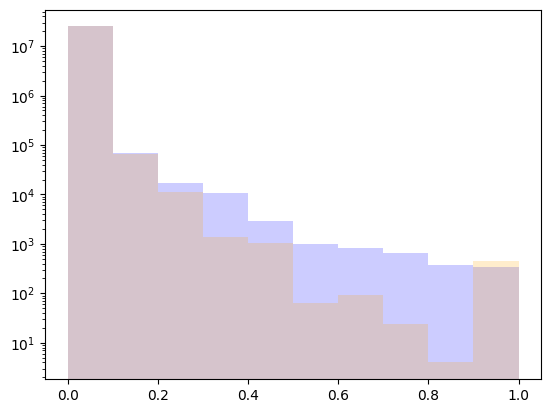

In [42]:
# histogram of connection strengths
plt.hist(inprop.data, alpha=0.2, label="inprop", color="blue")
plt.hist(outprop.data, alpha=0.2, label="outprop", color="orange")
plt.yscale("log")
plt.show()

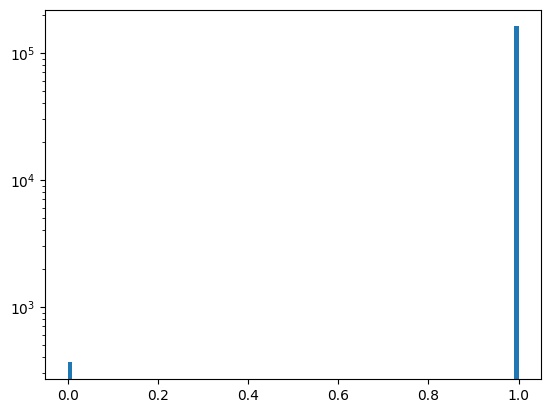

In [43]:
# histogram of column sums
colsums = inprop.sum(axis=0)
plt.hist(colsums.A1, bins=100)
plt.yscale("log")
plt.show()

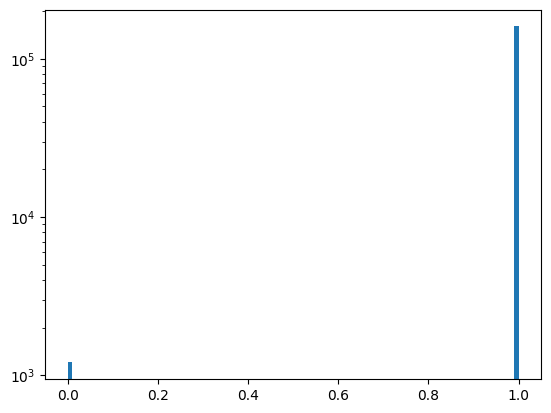

In [44]:
# histogram of row sums
rowsums = outprop.sum(axis=1)
plt.hist(rowsums.A1, bins=100)
plt.yscale("log")
plt.show()

# add hex coordinates

In [45]:
cols = pd.read_csv(
    "https://raw.githubusercontent.com/YijieYin/connectome_interpreter/refs/heads/main/connectome_interpreter/data/Nern2024/ME-columnar-cells-hex-location.csv"
)
cols["coords"] = cols["x"].astype(str) + "," + cols["y"].astype(str)
# make longer, remove columns hex1_id, hex2_id, x, y
cols = cols[
    [
        "L1",
        "L2",
        "L3",
        "L5",
        "Mi1",
        "Mi4",
        "Mi9",
        "C2",
        "C3",
        "Tm1",
        "Tm2",
        "Tm4",
        "Tm9",
        "Tm20",
        "T1",
        "coords",
    ]
].melt(id_vars=["coords"], var_name="cell_type", value_name="bodyId")
cols = cols[~cols.bodyId.isna()]
cols["bodyId"] = cols["bodyId"].astype(int)
cols

,coords,cell_type,bodyId
0,"6,8",L1,94444
1,"7,9",L1,65625
2,"9,11",L1,77697
3,"3,7",L1,107494
4,"4,8",L1,90008
...,...,...,...
13795,"-4,68",T1,71662
13796,"-3,69",T1,72225
13797,"-3,69",T1,72225
13798,"-2,70",T1,66447


In [46]:
# map from bodyid to coordinates
bodyid_to_coords = cols.set_index("bodyId")["coords"].to_dict()
selected_meta["coords"] = selected_meta.bodyid.map(bodyid_to_coords)
selected_meta[["type", "coords"]].value_counts().reset_index().sort_values("type")

,type,coords,count
3028,C2,"-13,33",1
4479,C2,"5,45",1
4505,C2,"-6,16",1
4716,C2,"-13,51",1
5266,C2,"-2,22",1
...,...,...,...
13137,Tm9,"8,42",1
13162,Tm9,"19,43",1
13187,Tm9,"-4,16",1
13223,Tm9,"4,10",1


In [47]:
# save to csv, one row is one neuron
selected_meta.loc[:, ["idx"]] = selected_meta.bodyid.map(nodes_to_idx)
selected_meta.loc[:, ["sign"]] = selected_meta.top_nt.map(nt_value)
selected_meta.rename(columns={"combined_type": "cell_type"}, inplace=True)

# adult, right hemisphere, neuron level, selected_meta information
selected_meta.to_csv("../data/maleCNS/mcns_all_neuron_meta.csv")

In [48]:
selected_meta

,bodyid,flywireType,group,hemibrainType,instance,itoleeHl,somaSide,statusLabel,superclass,supertype,...,serialMotif,receptorType,somaLocation,tosomaLocation,status,top_nt,cell_type,coords,idx,sign
0,10001,DNp01,10001.0,Giant Fiber,DNp01(GF)_R,putative_primary,R,Roughly traced,descending_neuron,NaN,...,NaN,NaN,"[37124, 22258, 36274]",None,Traced,acetylcholine,DNp01,NaN,0,1
1,10002,OCG01d,10002.0,OCG01,OCG01d_L,NaN,L,Roughly traced,visual_projection,NaN,...,NaN,NaN,"[50214, 10279, 27497]",None,Traced,acetylcholine,OCG01d,NaN,1,1
2,10003,VCH,10003.0,VCH,VCH_R,putative_primary,R,Prelim Roughly traced,visual_centrifugal,NaN,...,NaN,NaN,"[46716, 21029, 15714]",None,Traced,gaba,VCH,NaN,2,-1
3,10005,AOTU019,10005.0,AOTU019,AOTU019_R,putative_primary,R,Roughly traced,cb_intrinsic,NaN,...,NaN,NaN,"[41190, 18491, 12885]",None,Traced,gaba,AOTU019,NaN,3,-1
4,10006,"VS1,VS2,VS3,VS4,VS5,VS6,VS7,VS8",10006.0,VS,VS_L,no_lineage,L,Prelim Roughly traced,visual_projection,10006,...,NaN,NaN,"[69604, 28368, 42459]",None,Traced,acetylcholine,VS,NaN,4,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
210626,1349927540,NaN,NaN,NaN,NaN,NaN,NaN,Reviewed,vnc_sensory,NaN,...,NaN,NaN,None,None,Traced,acetylcholine,SNxx33,NaN,161411,1
210837,1387178136,NaN,NaN,NaN,NaN,NaN,NaN,Reviewed,vnc_sensory,NaN,...,NaN,NaN,None,None,Traced,acetylcholine,SNpp45,NaN,161412,1
210905,1399810824,NaN,NaN,NaN,NaN,NaN,NaN,Reviewed,vnc_sensory,NaN,...,NaN,NaN,None,None,Traced,acetylcholine,SNta34,NaN,161413,1
211084,1434599043,NaN,NaN,NaN,NaN,NaN,NaN,Reviewed,vnc_sensory,NaN,...,NaN,NaN,None,None,Traced,acetylcholine,SNta31,NaN,161414,1
